# **CS471 Final Project: Breast Cancer Survival**, *by Jason Stys*
Random forest and Logistic Regression used to predict the chances and length of survival of breast cancer based on factors/information of the cancer and or the individual, can give predictions based on one or some or all factors, as shown in the Breast_cancer.csv, a 3 year old data base from https://www.kaggle.com/datasets/reihanenamdari/breast-cancer by Reihaneh Namdari.

In [ ]:
# -----------------------------
# Breast Cancer Survival Project
# -----------------------------

# Import required libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import classification_report, mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
data = pd.read_csv("Breast_Cancer.csv")  # Change path as needed

# Clean column names
data.columns = data.columns.str.strip()

# Rename and prepare target column
data.rename(columns={'Status': 'Survival_Status'}, inplace=True)
data['Survival_Status'] = data['Survival_Status'].map({'Alive': 1, 'Dead': 0})

# Define features and targets
features = [
    'Age', 'Race', 'Marital Status', 'T Stage', 'N Stage', '6th Stage',
    'differentiate', 'Grade', 'A Stage', 'Tumor Size',
    'Estrogen Status', 'Progesterone Status',
    'Regional Node Examined', 'Reginol Node Positive'
]
X = data[features]
y_class = data['Survival_Status']
y_reg = data['Survival Months']

# Separate column types
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(include='number').columns.tolist()

# Preprocessing pipelines
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
preprocessor = ColumnTransformer([
    ('cat', categorical_transformer, categorical_cols),
    ('num', numeric_transformer, numerical_cols)
])

# Classification pipelines
clf_pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])
clf_pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

# Regression pipelines
reg_pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])
reg_pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Split data
X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test = train_test_split(
    X, y_class, y_reg, test_size=0.2, random_state=42
)

# Train models
clf_pipeline_rf.fit(X_train, y_class_train)
clf_pipeline_lr.fit(X_train, y_class_train)
reg_pipeline_rf.fit(X_train, y_reg_train)
reg_pipeline_lr.fit(X_train, y_reg_train)

# Predict
y_pred_class_rf = clf_pipeline_rf.predict(X_test)
y_pred_class_lr = clf_pipeline_lr.predict(X_test)
y_pred_reg_rf = reg_pipeline_rf.predict(X_test)
y_pred_reg_lr = reg_pipeline_lr.predict(X_test)

# Classification performance
print("Random Forest Classification Report:")
print(classification_report(y_class_test, y_pred_class_rf))

print("\n Logistic Regression Classification Report:")
print(classification_report(y_class_test, y_pred_class_lr))

# Regression metrics
print("\n Regression Metrics (Random Forest):")
print("MAE:", mean_absolute_error(y_reg_test, y_pred_reg_rf))
# Calculate RMSE manually
mse_rf = mean_squared_error(y_reg_test, y_pred_reg_rf)
rmse_rf = np.sqrt(mse_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_score(y_reg_test, y_pred_reg_rf))

print("\n Regression Metrics (Linear Regression):")
print("MAE:", mean_absolute_error(y_reg_test, y_pred_reg_lr))
# Calculate RMSE manually
mse_lr = mean_squared_error(y_reg_test, y_pred_reg_lr)
rmse_lr = np.sqrt(mse_lr)
print("RMSE:", rmse_lr)
print("R²:", r2_score(y_reg_test, y_pred_reg_lr))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.16      0.25       120
           1       0.87      0.98      0.92       685

    accuracy                           0.85       805
   macro avg       0.71      0.57      0.58       805
weighted avg       0.82      0.85      0.82       805


 Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.30      0.62      0.40       120
           1       0.92      0.75      0.82       685

    accuracy                           0.73       805
   macro avg       0.61      0.68      0.61       805
weighted avg       0.83      0.73      0.76       805


 Regression Metrics (Random Forest):
MAE: 18.996952942916295
RMSE: 23.251997990289258
R²: -0.011584036888036442

 Regression Metrics (Linear Regression):
MAE: 18.41278373189068
RMSE: 22.467427629701387
R²: 0.055530110443239744


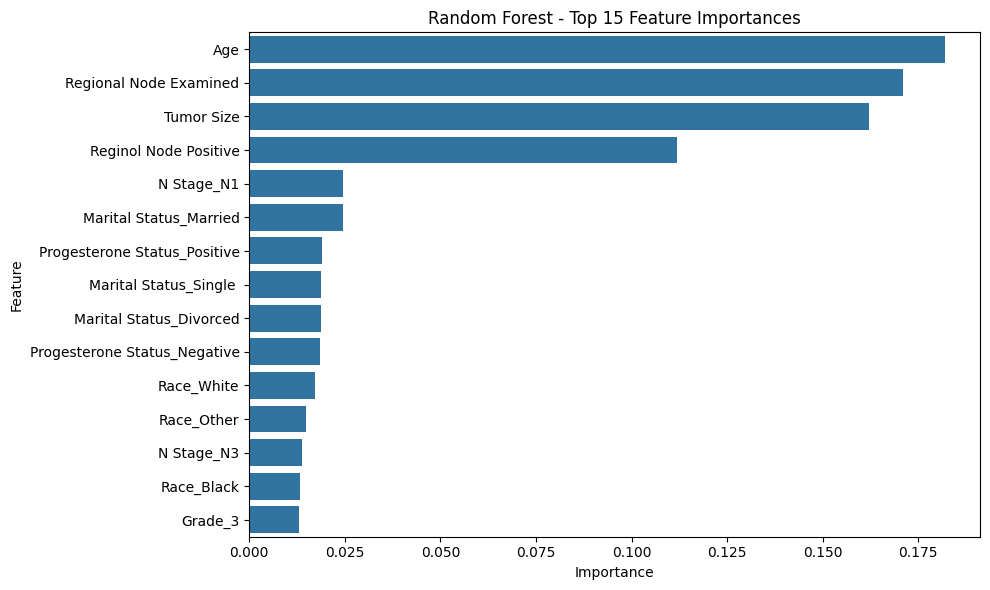

/tmp/ipython-input-1098734224.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lr_coefs_sorted.values, y=lr_coefs_sorted.index, palette="coolwarm")


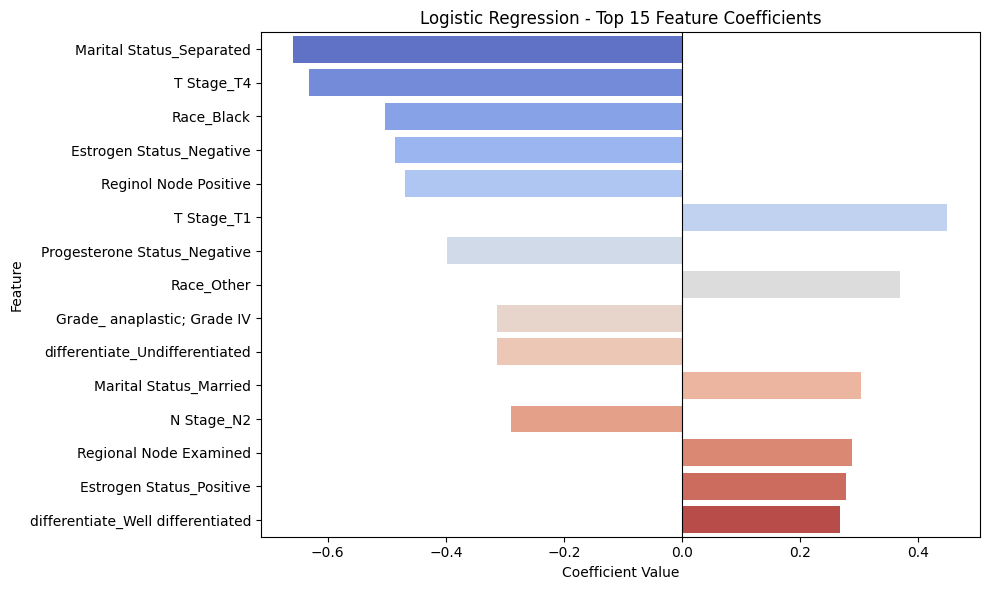

In [ ]:
# -----------------------------
# Feature Importance - Random Forest
# -----------------------------
# Extract the trained Random Forest model
rf_model = clf_pipeline_rf.named_steps['classifier']
# Get feature names after one-hot encoding
encoded_features = clf_pipeline_rf.named_steps['preprocessor'].transformers_[0][1] \
    .named_steps['encoder'].get_feature_names_out(categorical_cols)
all_features = np.concatenate([encoded_features, numerical_cols])

# Create DataFrame of importances
rf_importances = pd.Series(rf_model.feature_importances_, index=all_features)
rf_importances_sorted = rf_importances.sort_values(ascending=False)[:15]  # Top 15

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=rf_importances_sorted.values, y=rf_importances_sorted.index)
plt.title("Random Forest - Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


# -----------------------------
# Coefficient Plot - Logistic Regression
# -----------------------------
lr_model = clf_pipeline_lr.named_steps['classifier']
coefficients = lr_model.coef_[0]  # Binary classification → one set of coefficients

# Create DataFrame of coefficients
lr_coefs = pd.Series(coefficients, index=all_features)
lr_coefs_sorted = lr_coefs.sort_values(key=abs, ascending=False)[:15]  # Top 15 by magnitude

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=lr_coefs_sorted.values, y=lr_coefs_sorted.index, palette="coolwarm")
plt.title("Logistic Regression - Top 15 Feature Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()



🔹 Race value counts:
Race
White    3413
Other     320
Black     291
Name: count, dtype: int64

🔹 Marital Status value counts:
Marital Status
Married      2643
Single        615
Divorced      486
Widowed       235
Separated      45
Name: count, dtype: int64

🔹 T Stage value counts:
T Stage
T2    1786
T1    1603
T3     533
T4     102
Name: count, dtype: int64

🔹 N Stage value counts:
N Stage
N1    2732
N2     820
N3     472
Name: count, dtype: int64

🔹 6th Stage value counts:
6th Stage
IIA     1305
IIB     1130
IIIA    1050
IIIC     472
IIIB      67
Name: count, dtype: int64

🔹 differentiate value counts:
differentiate
Moderately differentiated    2351
Poorly differentiated        1111
Well differentiated           543
Undifferentiated               19
Name: count, dtype: int64

🔹 Grade value counts:
Grade
2                        2351
3                        1111
1                         543
 anaplastic; Grade IV      19
Name: count, dtype: int64

🔹 A Stage value counts:
A Stage
Regi

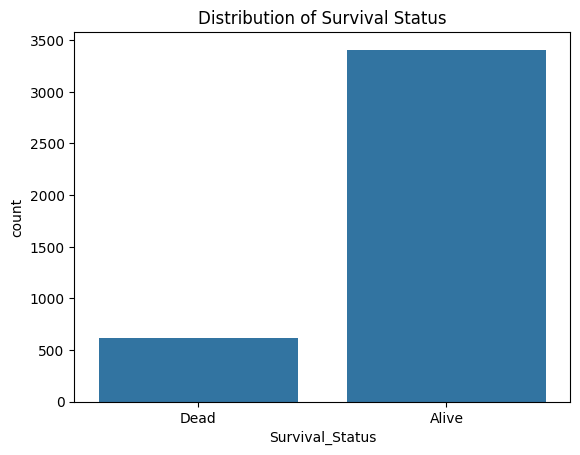

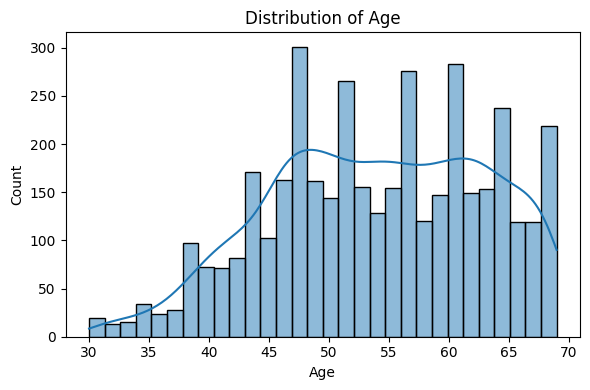

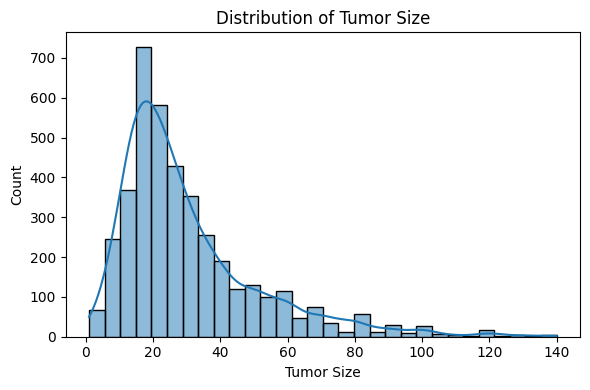

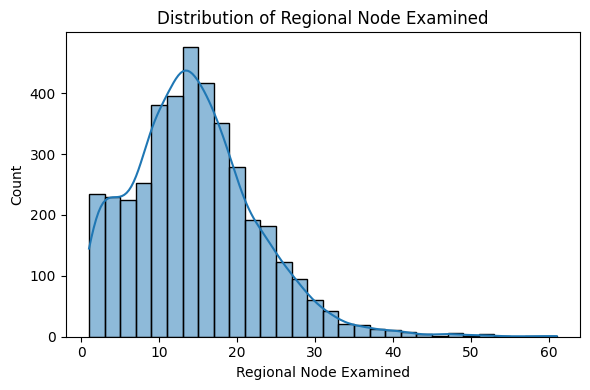

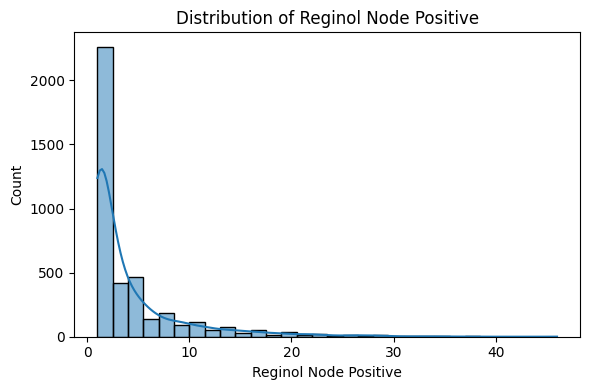

In [ ]:
# Hyperparameter tuning and EDA (excluding missing value imputation, not needed)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import classification_report, mean_absolute_error, mean_squared_error, r2_score

# Load dataset
data = pd.read_csv("Breast_Cancer.csv")
data.columns = data.columns.str.strip()
data.rename(columns={'Status': 'Survival_Status'}, inplace=True)
data['Survival_Status'] = data['Survival_Status'].map({'Alive': 1, 'Dead': 0})

# Define features and targets
features = [
    'Age', 'Race', 'Marital Status', 'T Stage', 'N Stage', '6th Stage',
    'differentiate', 'Grade', 'A Stage', 'Tumor Size',
    'Estrogen Status', 'Progesterone Status',
    'Regional Node Examined', 'Reginol Node Positive'
]
X = data[features]
y_class = data['Survival_Status']
y_reg = data['Survival Months']

# Separate column types
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(include='number').columns.tolist()

# EDA: Value counts and class balance
class_balance = data['Survival_Status'].value_counts(normalize=True)
for col in categorical_cols:
    print(f"\n🔹 {col} value counts:")
    print(data[col].value_counts())

# Plot class balance
sns.countplot(x='Survival_Status', data=data)
plt.title("Distribution of Survival Status")
plt.xticks([0,1], ['Dead', 'Alive'])
plt.show()

# Plot distributions of numeric features
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(data[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# Preprocessing pipeline (no missing value imputation needed)
categorical_transformer = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])
numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])
preprocessor = ColumnTransformer([
    ('cat', categorical_transformer, categorical_cols),
    ('num', numeric_transformer, numerical_cols)
])

# Split data
X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test = train_test_split(
    X, y_class, y_reg, test_size=0.2, random_state=42
)

# Base pipelines
rf_clf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])
lr_clf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])
rf_reg_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])
lr_reg_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Hyperparameter grids
param_grid_rf_clf = {
    'classifier__n_estimators': [100],
    'classifier__max_depth': [None, 10],
    'classifier__min_samples_split': [2, 5],
}
param_grid_lr_clf = {
    'classifier__C': [0.1, 1],
    'classifier__solver': ['liblinear']
}
param_grid_rf_reg = {
    'regressor__n_estimators': [100],
    'regressor__max_depth': [None, 10],
    'regressor__min_samples_split': [2, 5],
}
param_grid_lr_reg = {
    'regressor__fit_intercept': [True, False]
}

# GridSearchCV for all models
grid_search_rf_clf = GridSearchCV(rf_clf_pipeline, param_grid_rf_clf, cv=3, scoring='f1', n_jobs=-1)
grid_search_lr_clf = GridSearchCV(lr_clf_pipeline, param_grid_lr_clf, cv=3, scoring='f1', n_jobs=-1)
grid_search_rf_reg = GridSearchCV(rf_reg_pipeline, param_grid_rf_reg, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search_lr_reg = GridSearchCV(lr_reg_pipeline, param_grid_lr_reg, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)

# Fit models
grid_search_rf_clf.fit(X_train, y_class_train)
grid_search_lr_clf.fit(X_train, y_class_train)
grid_search_rf_reg.fit(X_train, y_reg_train)
grid_search_lr_reg.fit(X_train, y_reg_train)

# Best models
best_rf_clf = grid_search_rf_clf.best_estimator_
best_lr_clf = grid_search_lr_clf.best_estimator_
best_rf_reg = grid_search_rf_reg.best_estimator_
best_lr_reg = grid_search_lr_reg.best_estimator_

# Predictions
y_pred_rf_class = best_rf_clf.predict(X_test)
y_pred_lr_class = best_lr_clf.predict(X_test)
y_pred_rf_reg = best_rf_reg.predict(X_test)
y_pred_lr_reg = best_lr_reg.predict(X_test)

# Reports
report_rf_class = classification_report(y_class_test, y_pred_rf_class)
report_lr_class = classification_report(y_class_test, y_pred_lr_class)
metrics_rf_reg = {
    "MAE": mean_absolute_error(y_reg_test, y_pred_rf_reg),
    "RMSE": np.sqrt(mean_squared_error(y_reg_test, y_pred_rf_reg)),
    "R2": r2_score(y_reg_test, y_pred_rf_reg)
}
metrics_lr_reg = {
    "MAE": mean_absolute_error(y_reg_test, y_pred_lr_reg),
    "RMSE": np.sqrt(mean_squared_error(y_reg_test, y_pred_reg_lr)),
    "R2": r2_score(y_reg_test, y_pred_reg_lr)
}

In [ ]:
display(data.head())

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Survival_Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,1
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,1
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,1
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,1
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,1


In [ ]:
data.info()
display(data.describe())
display(data.describe(include='object'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     4024 non-null   int64 
 1   Race                    4024 non-null   object
 2   Marital Status          4024 non-null   object
 3   T Stage                 4024 non-null   object
 4   N Stage                 4024 non-null   object
 5   6th Stage               4024 non-null   object
 6   differentiate           4024 non-null   object
 7   Grade                   4024 non-null   object
 8   A Stage                 4024 non-null   object
 9   Tumor Size              4024 non-null   int64 
 10  Estrogen Status         4024 non-null   object
 11  Progesterone Status     4024 non-null   object
 12  Regional Node Examined  4024 non-null   int64 
 13  Reginol Node Positive   4024 non-null   int64 
 14  Survival Months         4024 non-null   int64 
 15  Surv

,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months,Survival_Status
count,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000
mean,53.972167,30.473658,14.357107,4.158052,71.297962,0.846918
std,8.963134,21.119696,8.099675,5.109331,22.921430,0.360111
min,30.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,47.000000,16.000000,9.000000,1.000000,56.000000,1.000000
50%,54.000000,25.000000,14.000000,2.000000,73.000000,1.000000
75%,61.000000,38.000000,19.000000,5.000000,90.000000,1.000000
max,69.000000,140.000000,61.000000,46.000000,107.000000,1.000000


,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Estrogen Status,Progesterone Status
count,4024,4024,4024,4024,4024,4024,4024,4024,4024,4024
unique,3,5,4,3,5,4,4,2,2,2
top,White,Married,T2,N1,IIA,Moderately differentiated,2,Regional,Positive,Positive
freq,3413,2643,1786,2732,1305,2351,2351,3932,3755,3326


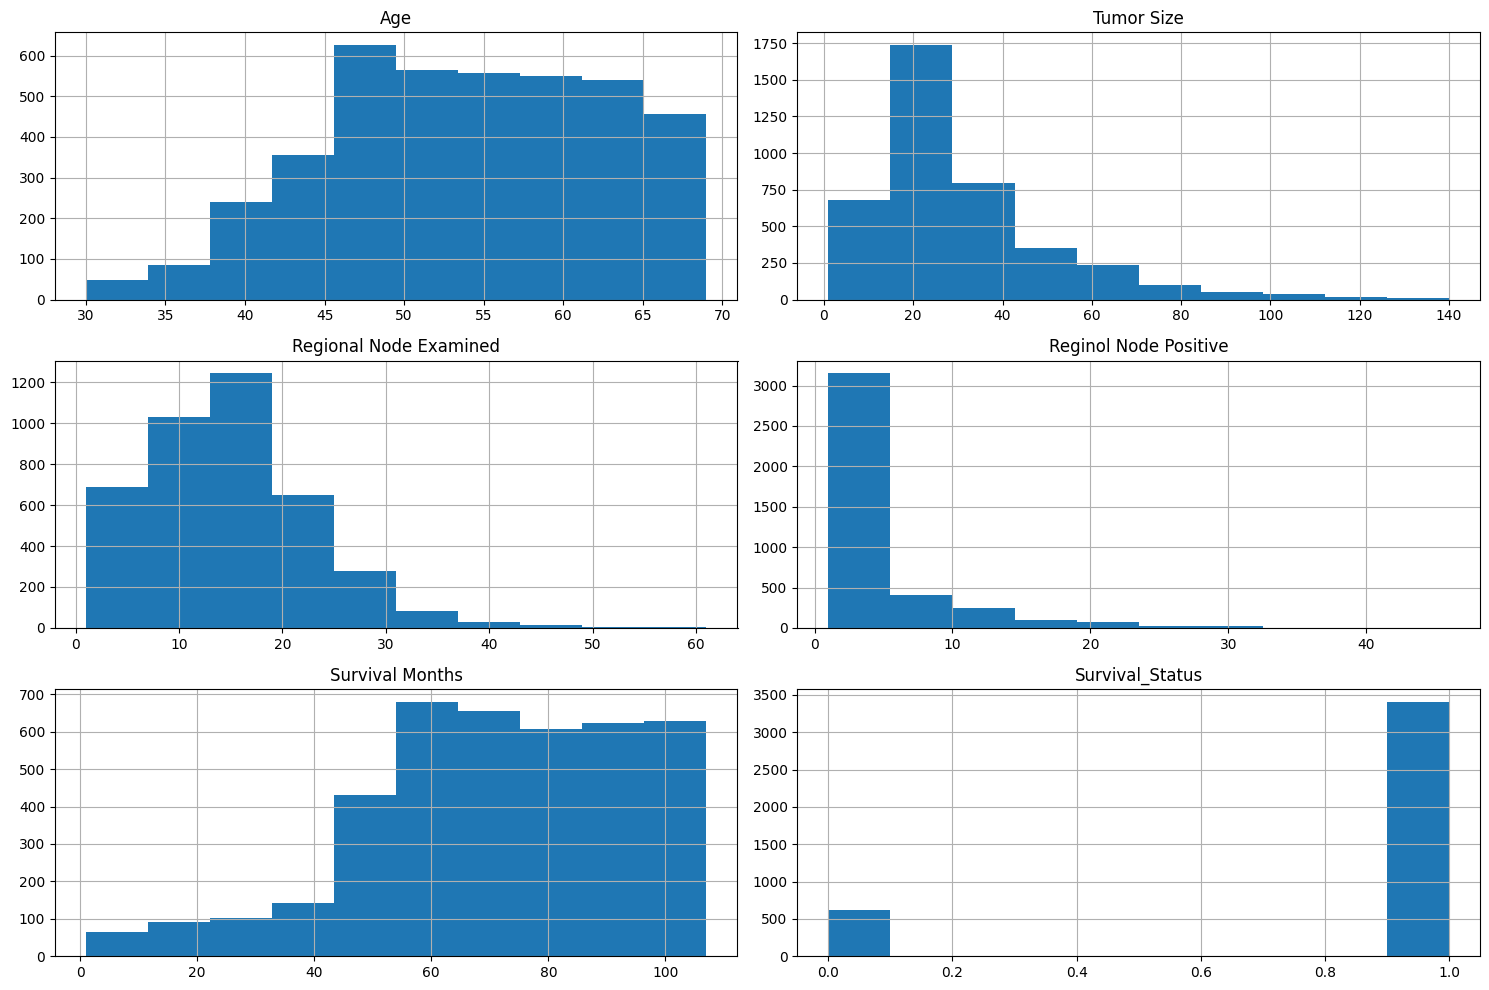

In [ ]:
numerical_cols = data.select_dtypes(include=np.number).columns.tolist()
data[numerical_cols].hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

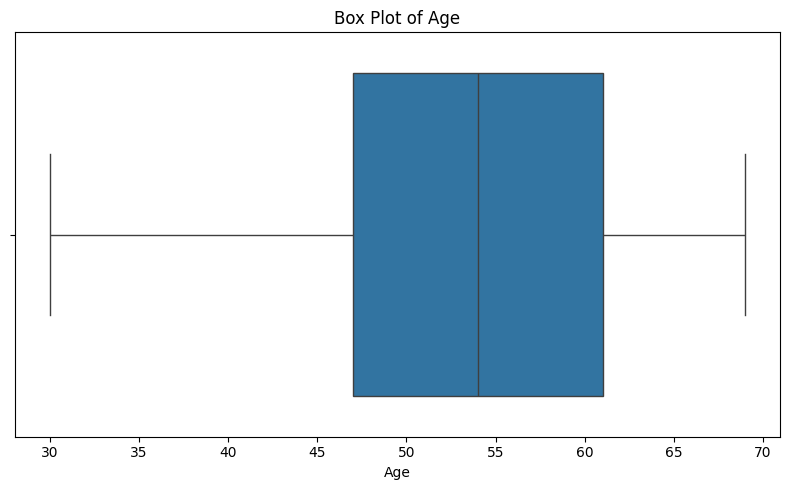

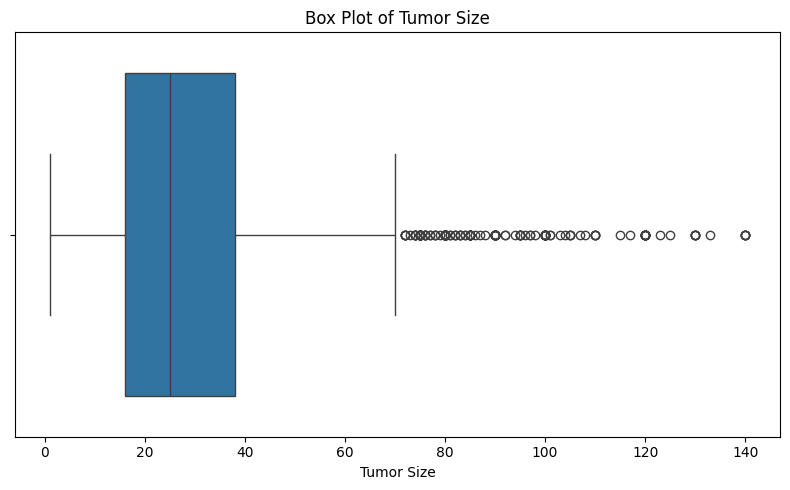

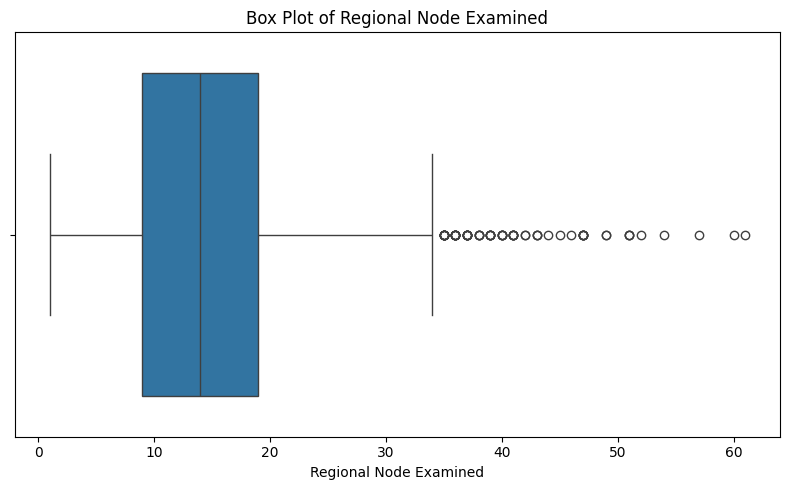

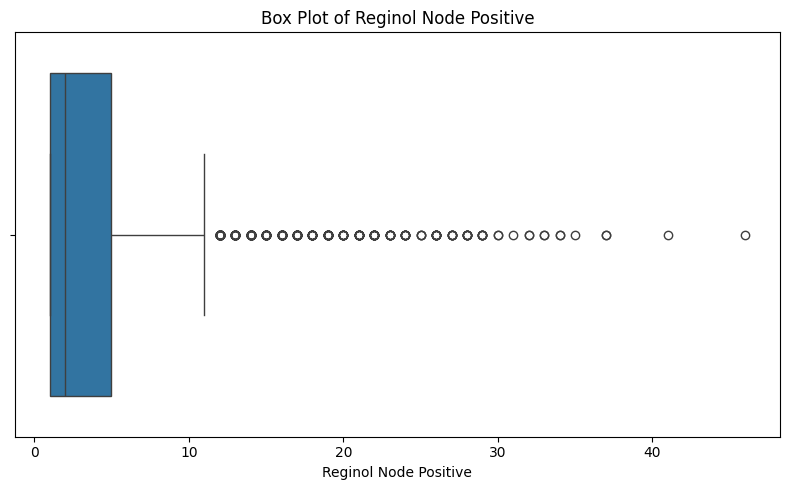

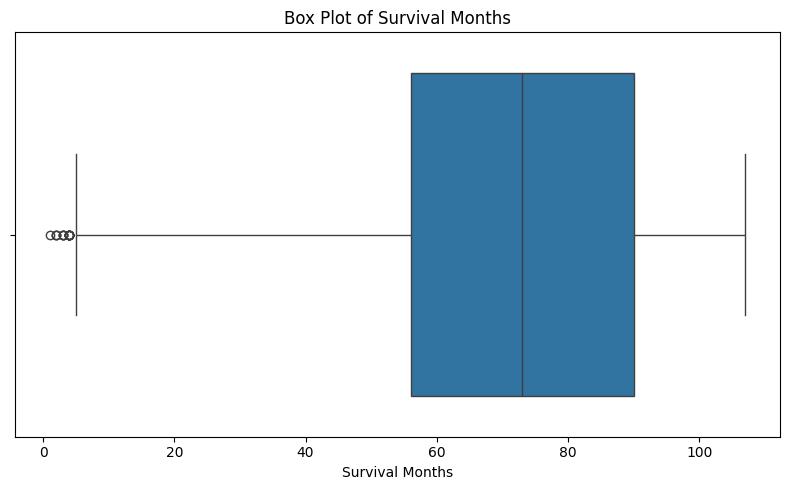

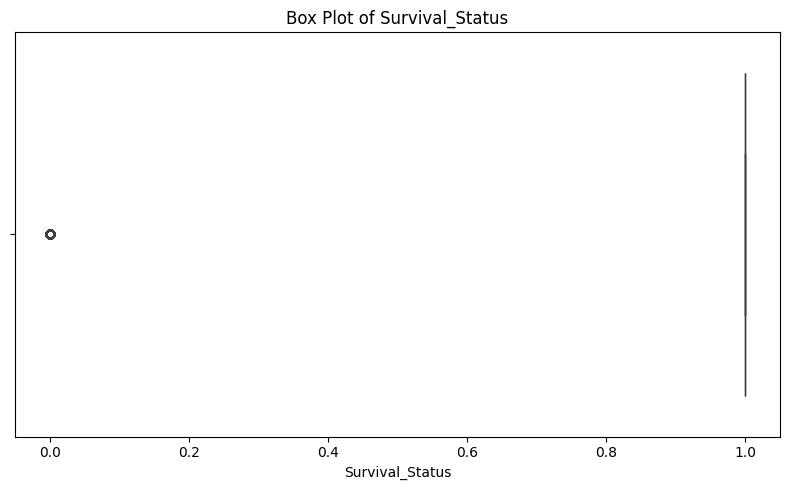

In [ ]:
for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=data[col])
    plt.title(f"Box Plot of {col}")
    plt.tight_layout()
    plt.show()

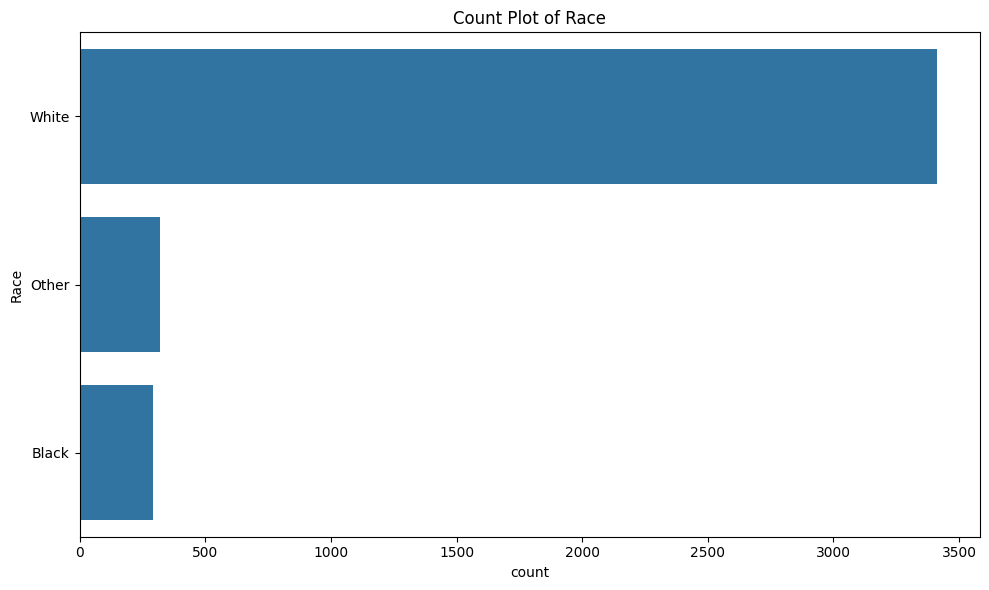

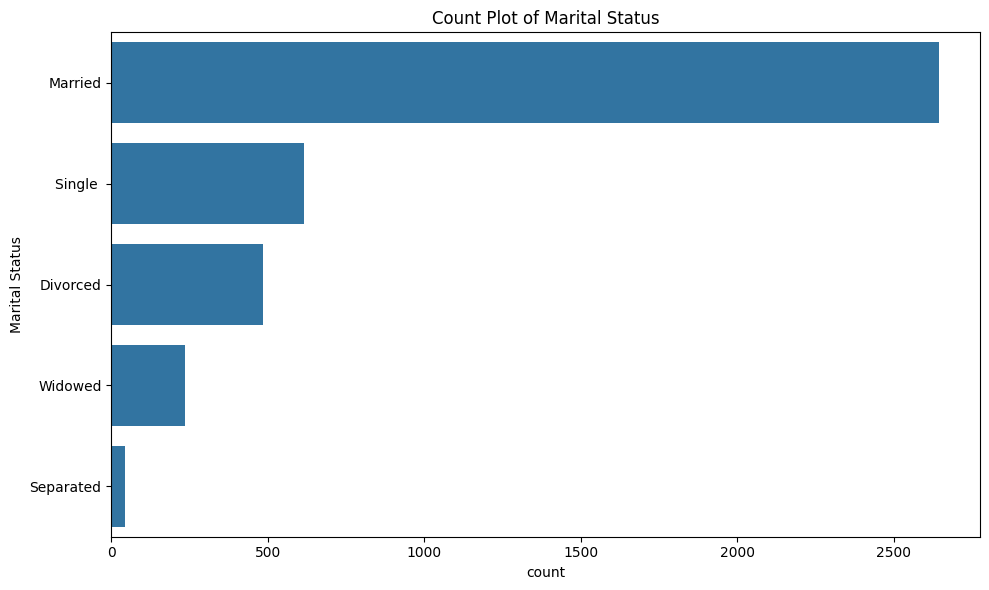

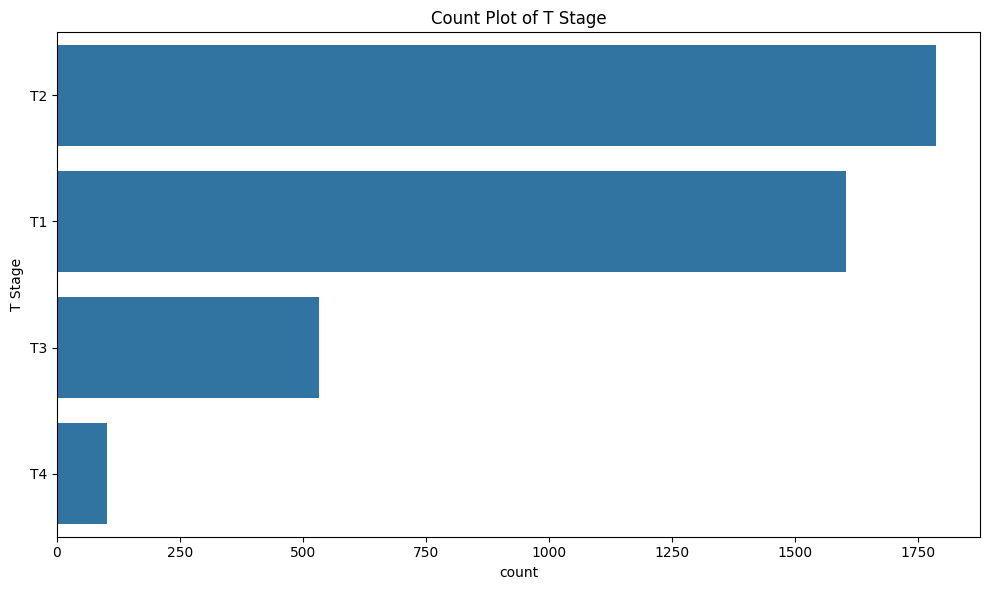

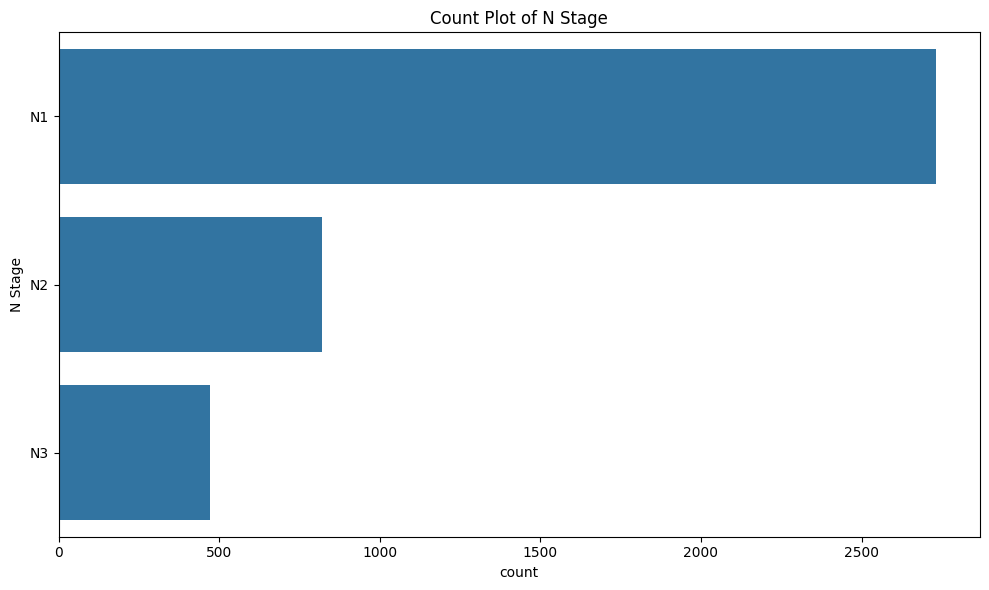

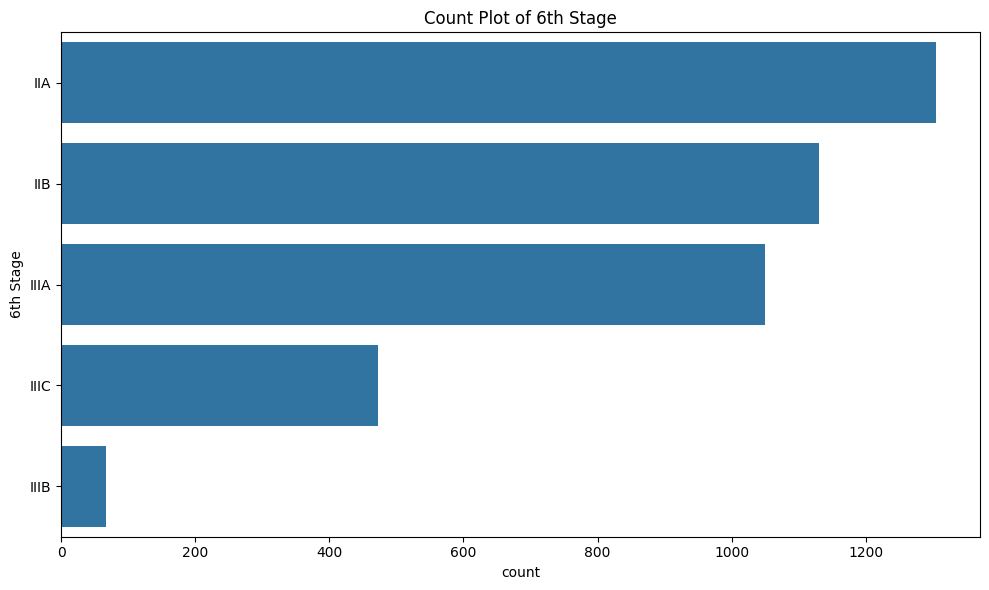

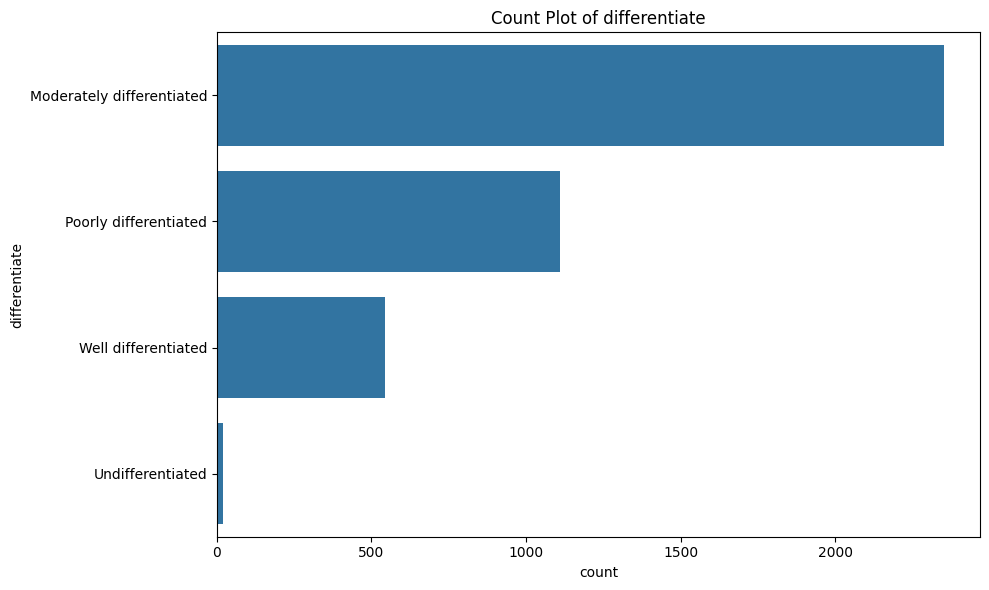

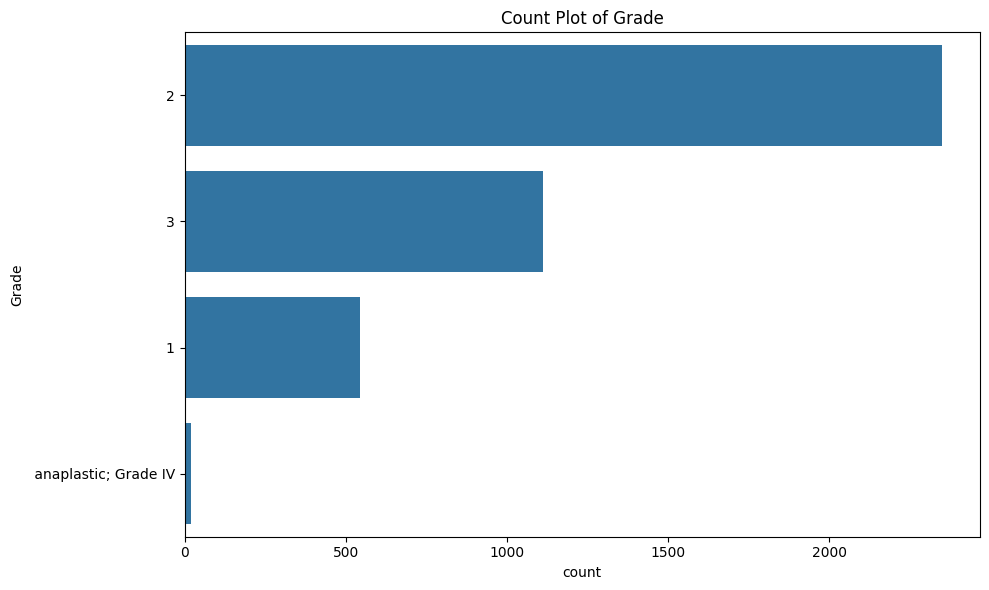

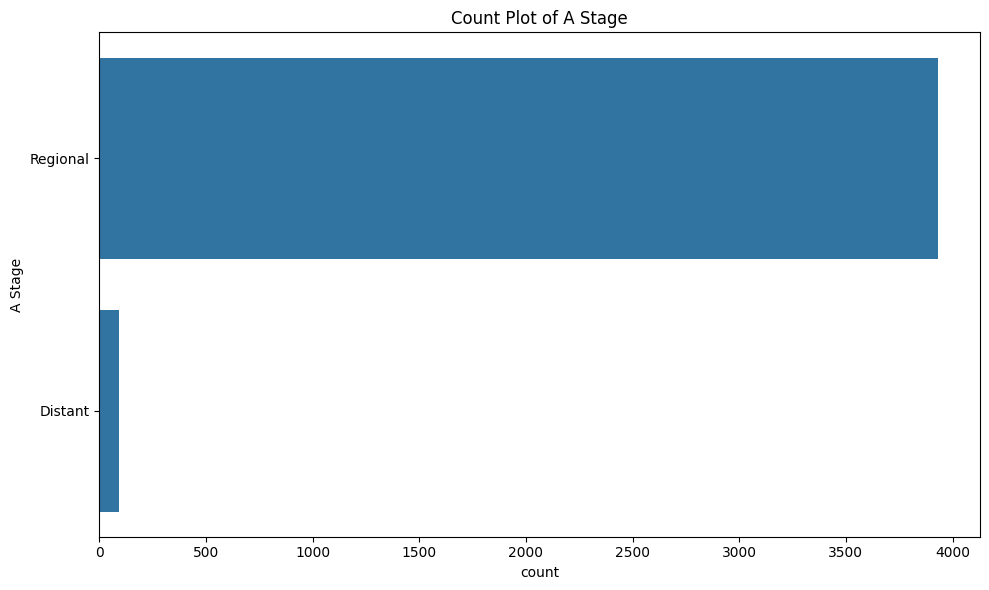

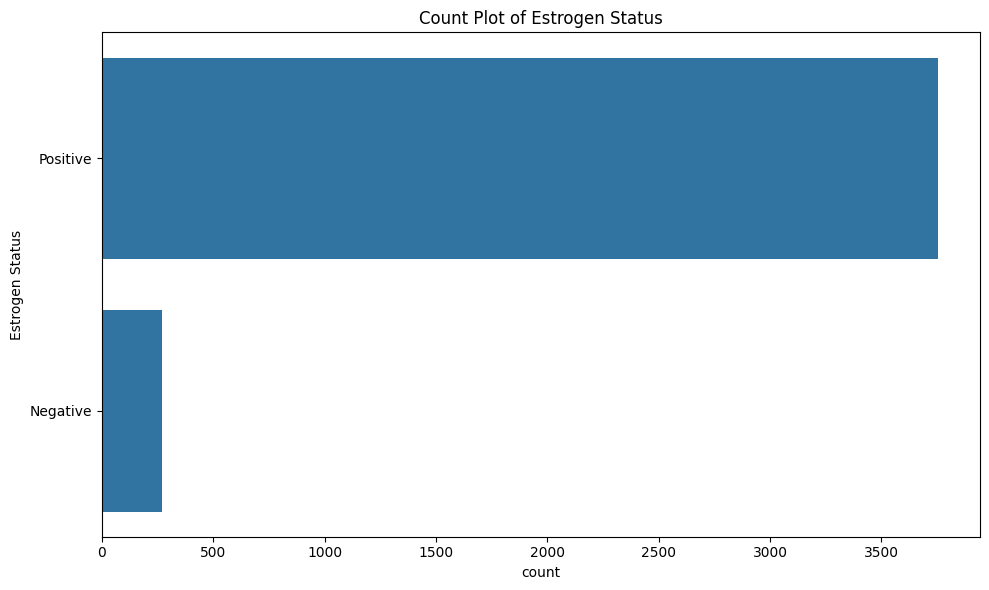

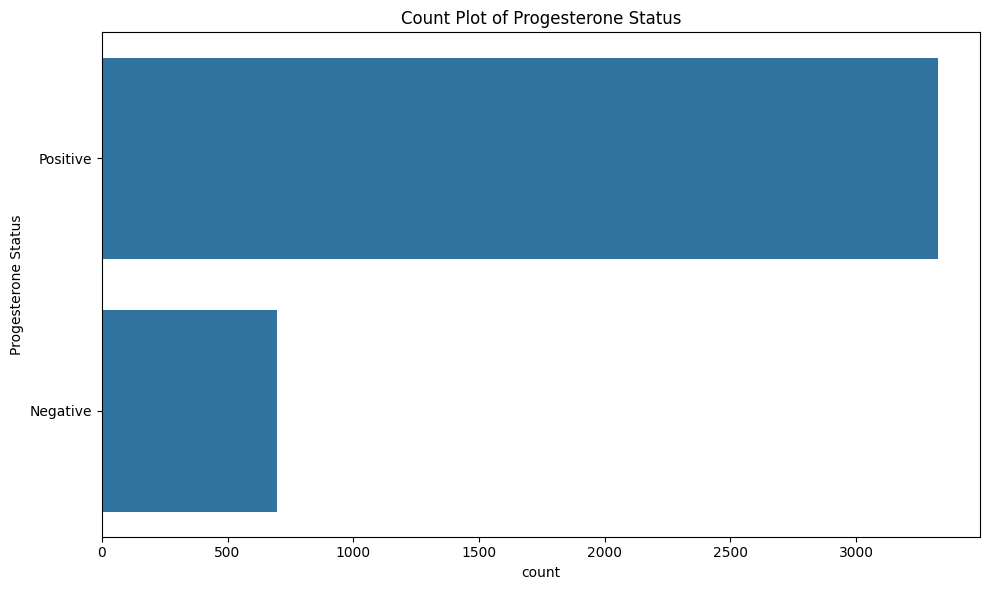

In [ ]:
categorical_cols = data.select_dtypes(include='object').columns.tolist()
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(y=data[col], order=data[col].value_counts().index)
    plt.title(f"Count Plot of {col}")
    plt.tight_layout()
    plt.show()

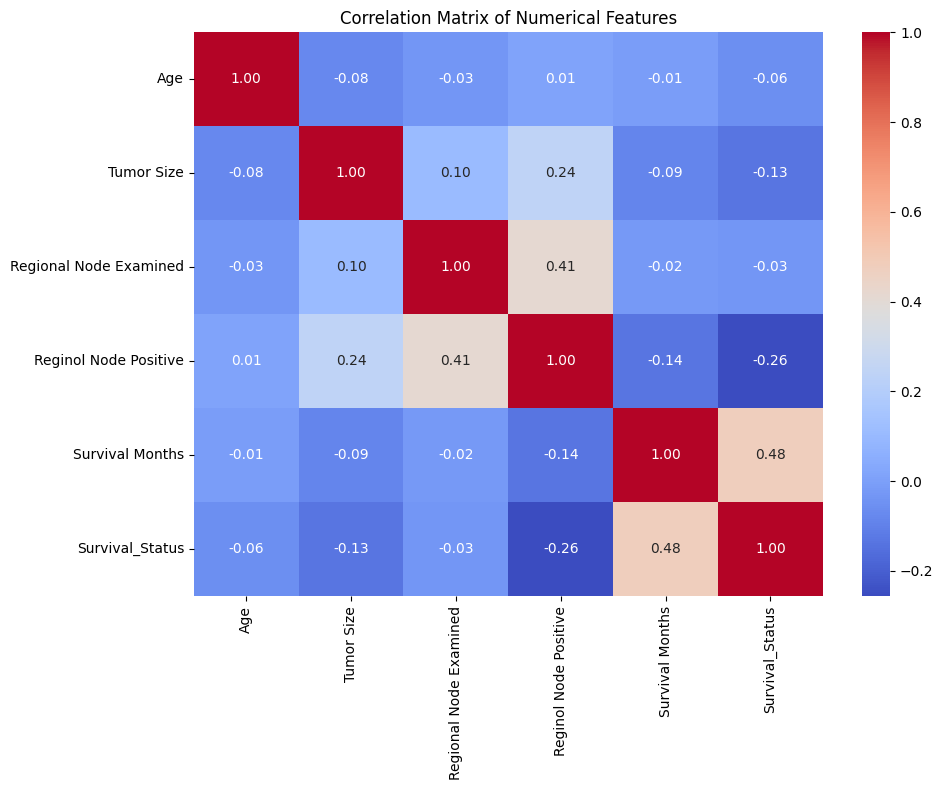

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(data[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

# Predict on the test set using the best Random Forest classifier
y_pred_class_rf_tuned = best_rf_clf.predict(X_test)

# Print classification report for the tuned Random Forest classifier
print("Tuned Random Forest Classification Report:")
print(classification_report(y_class_test, y_pred_class_rf_tuned))

# Predict on the test set using the best Logistic Regression classifier
y_pred_class_lr_tuned = best_lr_clf.predict(X_test)

# Print classification report for the tuned Logistic Regression classifier
print("\nTuned Logistic Regression Classification Report:")
print(classification_report(y_class_test, y_pred_class_lr_tuned))

Tuned Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.16      0.25       120
           1       0.87      0.98      0.92       685

    accuracy                           0.85       805
   macro avg       0.71      0.57      0.58       805
weighted avg       0.82      0.85      0.82       805


Tuned Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.30      0.62      0.40       120
           1       0.92      0.75      0.82       685

    accuracy                           0.73       805
   macro avg       0.61      0.68      0.61       805
weighted avg       0.83      0.73      0.76       805



In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Define hyperparameter distribution for RandomForestClassifier
param_dist_rf_clf = {
    'classifier__n_estimators': randint(low=100, high=500),
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_split': randint(low=2, high=20),
    'classifier__min_samples_leaf': randint(low=1, high=10)
}

# Instantiate RandomizedSearchCV for Random Forest Classifier
random_search_rf_clf = RandomizedSearchCV(
    clf_pipeline_rf,
    param_distributions=param_dist_rf_clf,
    n_iter=50,
    cv=5,
    random_state=42,
    scoring='f1',
    n_jobs=-1
)

# Fit the RandomizedSearchCV object to the training data
random_search_rf_clf.fit(X_train, y_class_train)

# Print the best parameters found
print("Best parameters for Random Forest Classifier:")
print(random_search_rf_clf.best_params_)

# Define hyperparameter grid for Logistic Regression Classifier
# Using a grid for Logistic Regression as the search space is typically smaller
param_grid_lr_clf = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l2', 'l1'], # l1 penalty requires a solver that supports it
    'classifier__solver': ['liblinear'] # 'liblinear' supports l1 and l2
}

# Instantiate GridSearchCV for Logistic Regression Classifier
# Using GridSearchCV since the grid is not too large
from sklearn.model_selection import GridSearchCV

grid_search_lr_clf = GridSearchCV(
    clf_pipeline_lr,
    param_grid=param_grid_lr_clf,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Fit the GridSearchCV object to the training data
grid_search_lr_clf.fit(X_train, y_class_train)

# Print the best parameters found
print("\nBest parameters for Logistic Regression Classifier:")
print(grid_search_lr_clf.best_params_)

# Store the best performing models
best_rf_clf = random_search_rf_clf.best_estimator_
best_lr_clf = grid_search_lr_clf.best_estimator_

Best parameters for Random Forest Classifier:
{'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 8, 'classifier__n_estimators': 108}

Best parameters for Logistic Regression Classifier:
{'classifier__C': 0.01, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}


In [ ]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from scipy.stats import randint

# Define hyperparameter distribution for RandomForestRegressor
param_dist_rf_reg = {
    'regressor__n_estimators': randint(low=100, high=500),
    'regressor__max_depth': [None, 10, 20, 30],
    'regressor__min_samples_split': randint(low=2, high=20),
    'regressor__min_samples_leaf': randint(low=1, high=10)
}

# Instantiate RandomizedSearchCV for Random Forest Regressor
random_search_rf_reg = RandomizedSearchCV(
    reg_pipeline_rf,
    param_distributions=param_dist_rf_reg,
    n_iter=50,
    cv=5,
    random_state=42,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# Fit the RandomizedSearchCV object to the training data
random_search_rf_reg.fit(X_train, y_reg_train)

# Print the best parameters found
print("Best parameters for Random Forest Regressor:")
print(random_search_rf_reg.best_params_)

# Define hyperparameter grid for Linear Regression Regressor
# Linear Regression has limited hyperparameters, fit_intercept is a common one.
param_grid_lr_reg = {
    'regressor__fit_intercept': [True, False]
}

# Instantiate GridSearchCV for Linear Regression Regressor
grid_search_lr_reg = GridSearchCV(
    reg_pipeline_lr,
    param_grid=param_grid_lr_reg,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# Fit the GridSearchCV object to the training data
grid_search_lr_reg.fit(X_train, y_reg_train)

# Print the best parameters found
print("\nBest parameters for Linear Regression Regressor:")
print(grid_search_lr_reg.best_params_)

# Store the best performing regression models
best_rf_reg = random_search_rf_reg.best_estimator_
best_lr_reg = grid_search_lr_reg.best_estimator_

Best parameters for Random Forest Regressor:
{'regressor__max_depth': 10, 'regressor__min_samples_leaf': 9, 'regressor__min_samples_split': 3, 'regressor__n_estimators': 439}

Best parameters for Linear Regression Regressor:
{'regressor__fit_intercept': True}


In [ ]:
# Predict on the test set using the best Random Forest regressor
y_pred_reg_rf_tuned = best_rf_reg.predict(X_test)

# Calculate and print regression metrics for tuned Random Forest
print("Tuned Regression Metrics (Random Forest):")
print("MAE:", mean_absolute_error(y_reg_test, y_pred_reg_rf_tuned))
mse_rf_tuned = mean_squared_error(y_reg_test, y_pred_reg_rf_tuned)
rmse_rf_tuned = np.sqrt(mse_rf_tuned)
print("RMSE:", rmse_rf_tuned)
print("R²:", r2_score(y_reg_test, y_pred_reg_rf_tuned))

# Predict on the test set using the best Linear Regression regressor
y_pred_reg_lr_tuned = best_lr_reg.predict(X_test)

# Calculate and print regression metrics for tuned Linear Regression
print("\nTuned Regression Metrics (Linear Regression):")
print("MAE:", mean_absolute_error(y_reg_test, y_pred_reg_lr_tuned))
mse_lr_tuned = mean_squared_error(y_reg_test, y_pred_reg_lr_tuned)
rmse_lr_tuned = np.sqrt(mse_lr_tuned)
print("RMSE:", rmse_lr_tuned)
print("R²:", r2_score(y_reg_test, y_pred_reg_lr_tuned))

Tuned Regression Metrics (Random Forest):
MAE: 18.41823412106387
RMSE: 22.516708181841956
R²: 0.051382324259452106

Tuned Regression Metrics (Linear Regression):
MAE: 18.41278373189068
RMSE: 22.467427629701387
R²: 0.055530110443239744


In [ ]:
%%writefile classification_model.py
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from scipy.stats import randint

def train_and_evaluate_classification_models(data_path="Breast_Cancer.csv"):
    """
    Loads data, preprocesses, trains and tunes classification models,
    and prints classification reports.
    """
    # Load the dataset
    data = pd.read_csv(data_path)
    data.columns = data.columns.str.strip()
    data.rename(columns={'Status': 'Survival_Status'}, inplace=True)
    data['Survival_Status'] = data['Survival_Status'].map({'Alive': 1, 'Dead': 0})

    # Define features and target
    features = [
        'Age', 'Race', 'Marital Status', 'T Stage', 'N Stage', '6th Stage',
        'differentiate', 'Grade', 'A Stage', 'Tumor Size',
        'Estrogen Status', 'Progesterone Status',
        'Regional Node Examined', 'Reginol Node Positive'
    ]
    X = data[features]
    y_class = data['Survival_Status']

    # Separate column types
    categorical_cols = X.select_dtypes(include='object').columns.tolist()
    numerical_cols = X.select_dtypes(include='number').columns.tolist()

    # Preprocessing pipelines
    categorical_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ])
    numeric_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    preprocessor = ColumnTransformer([
        ('cat', categorical_transformer, categorical_cols),
        ('num', numeric_transformer, numerical_cols)
    ])

    # Classification pipelines
    clf_pipeline_rf = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
    ])
    clf_pipeline_lr = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
    ])

    # Split data
    X_train, X_test, y_class_train, y_class_test = train_test_split(
        X, y_class, test_size=0.2, random_state=42
    )

    # Hyperparameter tuning for Random Forest Classifier
    param_dist_rf_clf = {
        'classifier__n_estimators': randint(low=100, high=500),
        'classifier__max_depth': [None, 10, 20, 30],
        'classifier__min_samples_split': randint(low=2, high=20),
        'classifier__min_samples_leaf': randint(low=1, high=10)
    }
    random_search_rf_clf = RandomizedSearchCV(
        clf_pipeline_rf,
        param_distributions=param_dist_rf_clf,
        n_iter=50,
        cv=5,
        random_state=42,
        scoring='f1',
        n_jobs=-1
    )
    random_search_rf_clf.fit(X_train, y_class_train)
    best_rf_clf = random_search_rf_clf.best_estimator_
    print("Best parameters for Random Forest Classifier:")
    print(random_search_rf_clf.best_params_)

    # Hyperparameter tuning for Logistic Regression Classifier
    param_grid_lr_clf = {
        'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'classifier__penalty': ['l2', 'l1'],
        'classifier__solver': ['liblinear']
    }
    grid_search_lr_clf = GridSearchCV(
        clf_pipeline_lr,
        param_grid=param_grid_lr_clf,
        cv=5,
        scoring='f1',
        n_jobs=-1
    )
    grid_search_lr_clf.fit(X_train, y_class_train)
    best_lr_clf = grid_search_lr_clf.best_estimator_
    print("\nBest parameters for Logistic Regression Classifier:")
    print(grid_search_lr_clf.best_params_)

    # Evaluate tuned models
    y_pred_class_rf_tuned = best_rf_clf.predict(X_test)
    print("\nTuned Random Forest Classification Report:")
    print(classification_report(y_class_test, y_pred_class_rf_tuned))

    y_pred_class_lr_tuned = best_lr_clf.predict(X_test)
    print("\nTuned Logistic Regression Classification Report:")
    print(classification_report(y_class_test, y_pred_class_lr_tuned))

    return best_rf_clf, best_lr_clf

if __name__ == '__main__':
    train_and_evaluate_classification_models()

Overwriting classification_model.py


In [ ]:
%%writefile regression_model.py
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import randint

def train_and_evaluate_regression_models(data_path="Breast_Cancer.csv"):
    """
    Loads data, preprocesses, trains and tunes regression models,
    and prints regression metrics.
    """
    # Load the dataset
    data = pd.read_csv(data_path)
    data.columns = data.columns.str.strip()
    data.rename(columns={'Status': 'Survival_Status'}, inplace=True)
    data['Survival_Status'] = data['Survival_Status'].map({'Alive': 1, 'Dead': 0})

    # Define features and target
    features = [
        'Age', 'Race', 'Marital Status', 'T Stage', 'N Stage', '6th Stage',
        'differentiate', 'Grade', 'A Stage', 'Tumor Size',
        'Estrogen Status', 'Progesterone Status',
        'Regional Node Examined', 'Reginol Node Positive'
    ]
    X = data[features]
    y_reg = data['Survival Months']

    # Separate column types
    categorical_cols = X.select_dtypes(include='object').columns.tolist()
    numerical_cols = X.select_dtypes(include='number').columns.tolist()

    # Preprocessing pipelines
    categorical_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ])
    numeric_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    preprocessor = ColumnTransformer([
        ('cat', categorical_transformer, categorical_cols),
        ('num', numeric_transformer, numerical_cols)
    ])

    # Regression pipelines
    reg_pipeline_rf = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(random_state=42))
    ])
    reg_pipeline_lr = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ])

    # Split data
    X_train, X_test, y_reg_train, y_reg_test = train_test_split(
        X, y_reg, test_size=0.2, random_state=42
    )

    # Hyperparameter tuning for Random Forest Regressor
    param_dist_rf_reg = {
        'regressor__n_estimators': randint(low=100, high=500),
        'regressor__max_depth': [None, 10, 20, 30],
        'regressor__min_samples_split': randint(low=2, high=20),
        'regressor__min_samples_leaf': randint(low=1, high=10)
    }
    random_search_rf_reg = RandomizedSearchCV(
        reg_pipeline_rf,
        param_distributions=param_dist_rf_reg,
        n_iter=50,
        cv=5,
        random_state=42,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    random_search_rf_reg.fit(X_train, y_reg_train)
    best_rf_reg = random_search_rf_reg.best_estimator_
    print("Best parameters for Random Forest Regressor:")
    print(random_search_rf_reg.best_params_)


    # Hyperparameter tuning for Linear Regression Regressor
    param_grid_lr_reg = {
        'regressor__fit_intercept': [True, False]
    }
    grid_search_lr_reg = GridSearchCV(
        reg_pipeline_lr,
        param_grid=param_grid_lr_reg,
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    grid_search_lr_reg.fit(X_train, y_reg_train)
    best_lr_reg = grid_search_lr_reg.best_estimator_
    print("\nBest parameters for Linear Regression Regressor:")
    print(grid_search_lr_reg.best_params_)

    # Evaluate tuned models
    y_pred_reg_rf_tuned = best_rf_reg.predict(X_test)
    print("\nTuned Regression Metrics (Random Forest):")
    print("MAE:", mean_absolute_error(y_reg_test, y_pred_reg_rf_tuned))
    rmse_rf_tuned = np.sqrt(mean_squared_error(y_reg_test, y_pred_reg_rf_tuned))
    print("RMSE:", rmse_rf_tuned)
    print("R²:", r2_score(y_reg_test, y_pred_reg_rf_tuned))

    y_pred_reg_lr_tuned = best_lr_reg.predict(X_test)
    print("\nTuned Regression Metrics (Linear Regression):")
    print("MAE:", mean_absolute_error(y_reg_test, y_pred_reg_lr_tuned))
    rmse_lr_tuned = np.sqrt(mean_squared_error(y_reg_test, y_pred_reg_lr_tuned))
    print("RMSE:", rmse_lr_tuned)
    print("R²:", r2_score(y_reg_test, y_pred_reg_lr_tuned))

    return best_rf_reg, best_lr_reg

if __name__ == '__main__':
    train_and_evaluate_regression_models()

Overwriting regression_model.py


In [ ]:
# Train classification and regression models with hyperparameter tuning
from classification_model import train_and_evaluate_classification_models
from regression_model import train_and_evaluate_regression_models
import joblib

print("--- Training and Tuning Classification Models ---")
best_rf_clf, best_lr_clf = train_and_evaluate_classification_models()

print("\n--- Training and Tuning Regression Models ---")
best_rf_reg, best_lr_reg = train_and_evaluate_regression_models()

# Save the best tuned models
joblib.dump(best_rf_clf, 'best_rf_clf.pkl')
joblib.dump(best_lr_clf, 'best_lr_clf.pkl')
joblib.dump(best_rf_reg, 'best_rf_reg.pkl')
joblib.dump(best_lr_reg, 'best_lr_reg.pkl')

print("\n Models trained and saved.")


--- Training and Tuning Classification Models ---
Best parameters for Random Forest Classifier:
{'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 8, 'classifier__n_estimators': 108}

Best parameters for Logistic Regression Classifier:
{'classifier__C': 0.01, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}

Tuned Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.28      0.34       120
           1       0.88      0.94      0.91       685

    accuracy                           0.84       805
   macro avg       0.65      0.61      0.62       805
weighted avg       0.81      0.84      0.82       805


Tuned Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.34      0.52      0.41       120
           1       0.91      0.82      0.86       685

    accuracy                           0.7

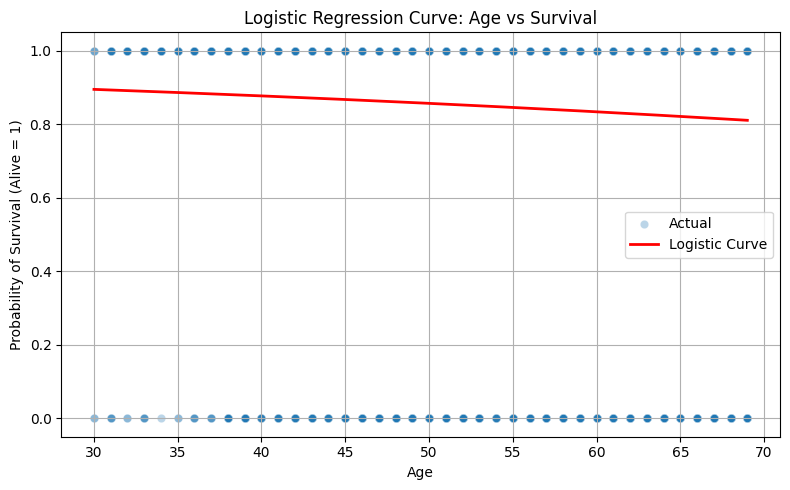

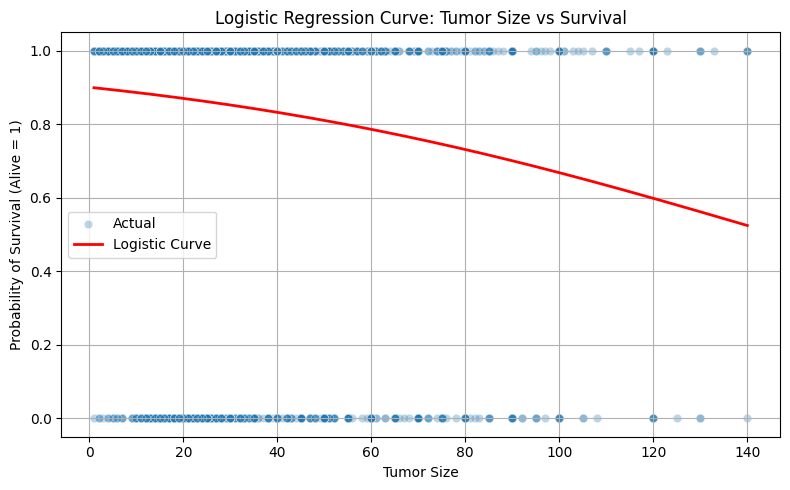

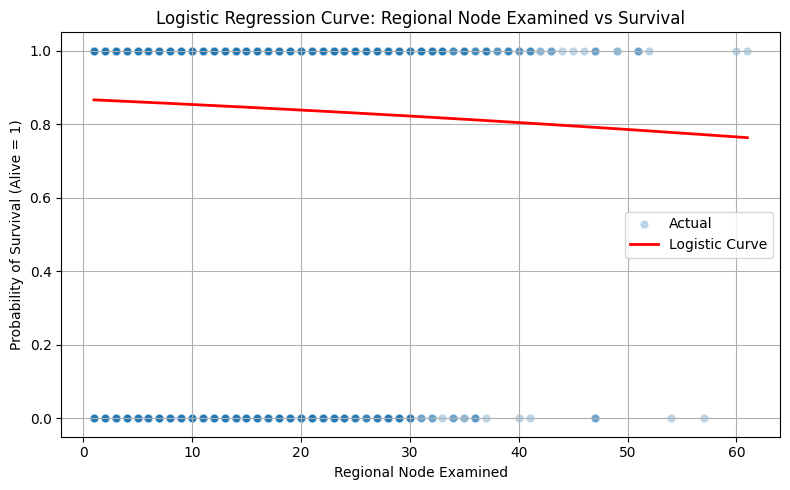

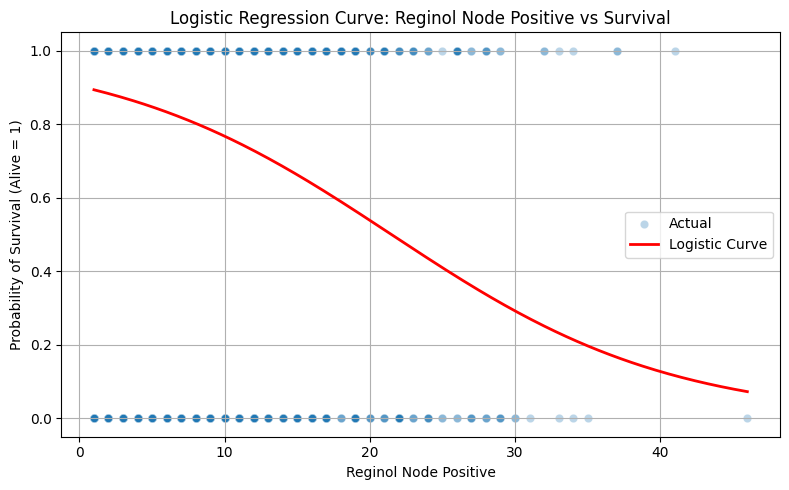

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

# Define numeric features
numeric_features = ['Age', 'Tumor Size', 'Regional Node Examined', 'Reginol Node Positive']

# Loop through each numeric feature and plot logistic regression curve
for feature in numeric_features:
    # Drop rows with missing data for this feature
    subset = data[[feature, 'Survival_Status']].dropna()

    X_feature = subset[[feature]].values
    y_target = subset['Survival_Status'].values

    # Fit basic logistic regression model (no preprocessing needed here)
    lr = LogisticRegression()
    lr.fit(X_feature, y_target)

    # Create range of X values for smooth curve
    x_range = np.linspace(X_feature.min(), X_feature.max(), 300).reshape(-1, 1)
    y_prob = lr.predict_proba(x_range)[:, 1]  # Probability of "Alive"

    # Plot actual data points and fitted sigmoid curve
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=X_feature.ravel(), y=y_target, alpha=0.3, label="Actual")
    plt.plot(x_range, y_prob, color='red', linewidth=2, label="Logistic Curve")
    plt.title(f"Logistic Regression Curve: {feature} vs Survival")
    plt.xlabel(feature)
    plt.ylabel("Probability of Survival (Alive = 1)")
    plt.legend()
    plt.tight_layout()
    plt.grid(True)
    plt.show()


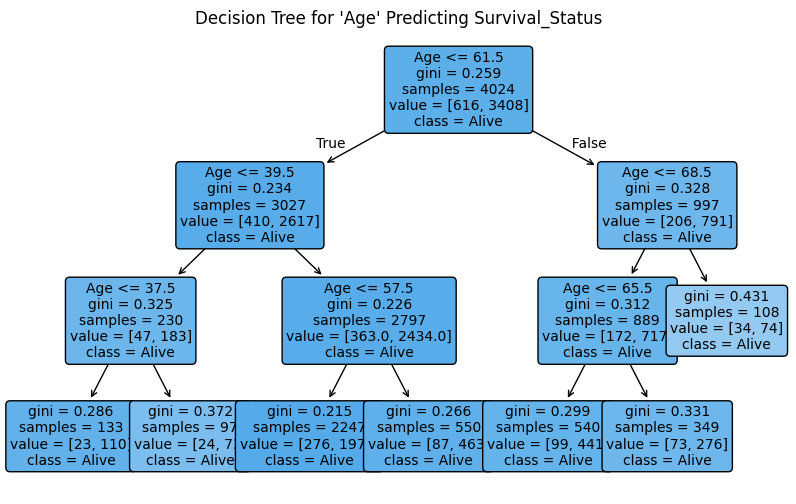

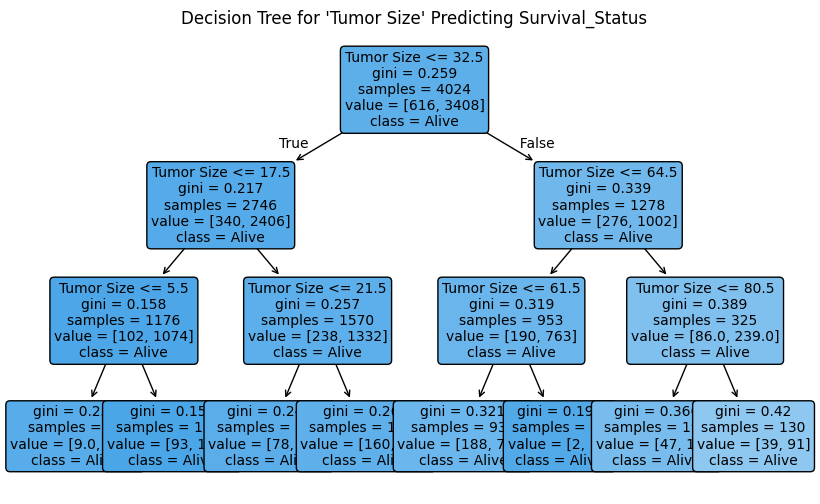

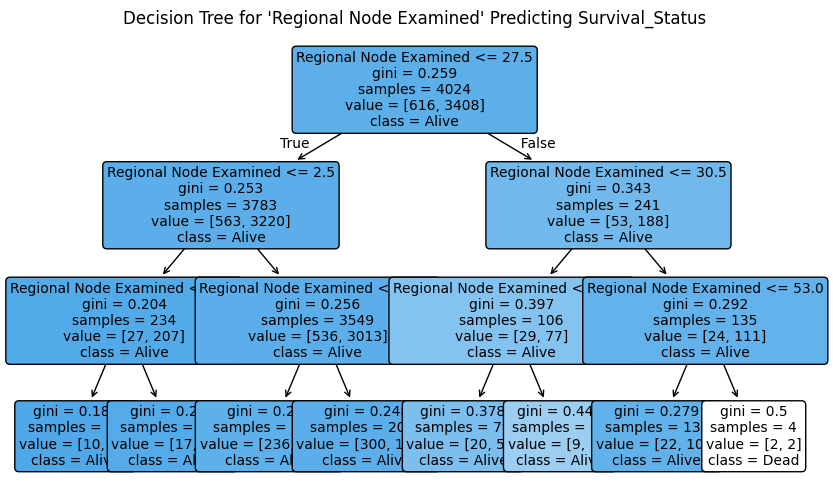

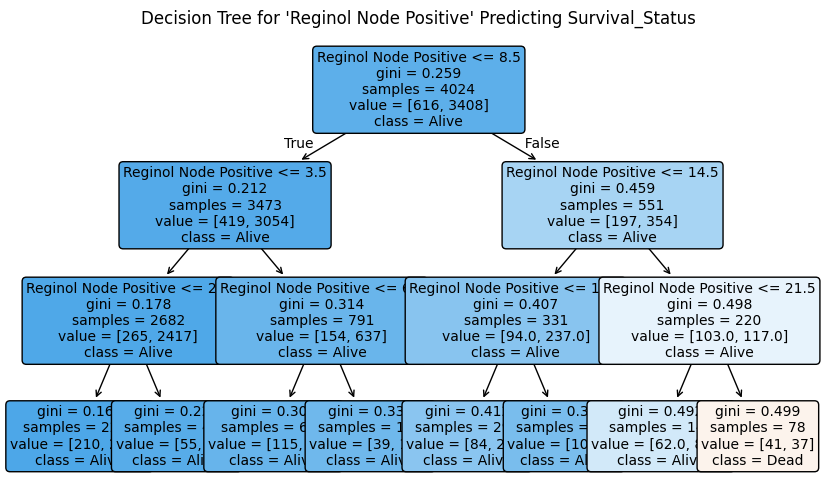

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Features to visualize individually
numeric_features = ['Age', 'Tumor Size', 'Regional Node Examined', 'Reginol Node Positive']

# Loop through each numeric feature
for feature in numeric_features:
    # Drop missing values for this feature
    subset = data[[feature, 'Survival_Status']].dropna()

    X_feature = subset[[feature]]
    y_target = subset['Survival_Status']

    # Train a simple decision tree on one feature
    tree = DecisionTreeClassifier(max_depth=3, random_state=42)
    tree.fit(X_feature, y_target)

    # Plot the decision tree
    plt.figure(figsize=(10, 6))
    plot_tree(
        tree,
        feature_names=[feature],
        class_names=["Dead", "Alive"],
        filled=True,
        rounded=True,
        fontsize=10
    )
    plt.title(f"Decision Tree for '{feature}' Predicting Survival_Status")
    plt.show()


In [ ]:
# Load saved models
import joblib

# Choose which models to use
best_rf_clf = joblib.load('best_rf_clf.pkl')  # or 'best_lr_clf.pkl'
best_rf_reg = joblib.load('best_rf_reg.pkl')  # or 'best_lr_reg.pkl'

print(" Models loaded and ready for prediction.")


✅ Models loaded and ready for prediction.


In [ ]:
def predict_user_outcome(user_input_dict, clf_model, reg_model):
    import pandas as pd
    import numpy as np

    all_features = [
        'Age', 'Race', 'Marital Status', 'T Stage', 'N Stage', '6th Stage',
        'differentiate', 'Grade', 'A Stage', 'Tumor Size',
        'Estrogen Status', 'Progesterone Status',
        'Regional Node Examined', 'Reginol Node Positive'
    ]

    user_input_complete = {feature: user_input_dict.get(feature, np.nan) for feature in all_features}
    user_df = pd.DataFrame([user_input_complete])

    survival_proba = clf_model.predict_proba(user_df)[0]
    death_proba = 1 - survival_proba[1]
    survival_percent = round(survival_proba[1] * 100, 2)
    death_percent = round(death_proba * 100, 2)

    months_predicted = reg_model.predict(user_df)[0]
    months_predicted = round(months_predicted, 1)

    print("\nPrediction Based on Your Input:")
    print(f" Likelihood of Survival: {survival_percent}%")
    print(f" Likelihood of Death: {death_percent}%")
    print(f" Estimated Months Left to Live: {months_predicted}")


In [ ]:
def ask_user_and_predict_tuned(clf_model, reg_model):
    import numpy as np

    print("\n Enter the following patient details (press Enter to skip any):\n")

    user_input_dict = {}

    input_fields = {
        'Age': float,
        'Race': str,
        'Marital Status': str,
        'T Stage': str,
        'N Stage': str,
        '6th Stage': str,
        'differentiate': str,
        'Grade': float,
        'A Stage': str,
        'Tumor Size': float,
        'Estrogen Status': str,
        'Progesterone Status': str,
        'Regional Node Examined': float,
        'Reginol Node Positive': float
    }

    for field, cast_type in input_fields.items():
        user_input = input(f"{field}: ").strip()
        if user_input == "":
            user_input_dict[field] = np.nan
        else:
            try:
                user_input_dict[field] = cast_type(user_input)
            except ValueError:
                print(f" Invalid input for {field}. Marked as missing.")
                user_input_dict[field] = np.nan

    predict_user_outcome(user_input_dict, clf_model, reg_model)


User input section rerun this part of the code bellow to reuse.

In [ ]:
# Run this only after loading the models
print("\n--- Interactive Prediction with Tuned Models ---")
ask_user_and_predict_tuned(best_rf_clf, best_rf_reg)



--- Interactive Prediction with Tuned Models ---

📝 Enter the following patient details (press Enter to skip any):

Age: 20
Race: white
Marital Status: married
T Stage: T1
N Stage: N1
6th Stage: IIA
differentiate: Poorly diffined 
Grade: 1
A Stage: regional
Tumor Size: 2
Estrogen Status: positive
Progesterone Status: positive
Regional Node Examined: 2
Reginol Node Positive: 1

🩺 Prediction Based on Your Input:
 Likelihood of Survival: 77.95%
 Likelihood of Death: 22.05%
 Estimated Months Left to Live: 66.1
